In [16]:
import sys
import os

# Add project root to Python path
sys.path.append(os.path.abspath(".."))

In [17]:
from src.grn_engine.graphml_parser import load_graphml
from src.grn_engine.io_mapping import run_grn_pipeline

In [18]:
model = load_graphml("../data/networks/test_minimal.graphml")

initial_state = [0.0] * len(model.node_names)

sensor_input = {
    "InCollisionImpulse": 1.0
}

final_state, outputs, history = run_grn_pipeline(
    model,
    initial_state=initial_state,
    sensors=sensor_input,
    steps=10
)

print("Final state:", final_state)
print("Outputs:", outputs)
print("History length:", len(history))

Final state: [1.0, 0.47615421381157164, 0.36396999452620477]
Outputs: {'OutStickiness': 0.36396999452620477}
History length: 11


In [19]:
stickiness_values = [state[2] for state in history]
signal_values = [state[1] for state in history]
input_values = [state[0] for state in history]

print("Input over time:", input_values)
print("SignalA over time:", signal_values)
print("Stickiness over time:", stickiness_values)

Input over time: [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]
SignalA over time: [0.0, 0.07310585786300049, 0.13890112993970094, 0.19811687480873133, 0.25141104519085866, 0.2993757985347733, 0.34254407654429647, 0.3813955267528673, 0.4163618319405811, 0.4478315066095235, 0.47615421381157164]
Stickiness over time: [0.0, 0.05, 0.09646170054050288, 0.13959069805878546, 0.17958569197660493, 0.2166384615011004, 0.25093367393990945, 0.28264863516978034, 0.31195305061471257, 0.3390088356506883, 0.36396999452620477]


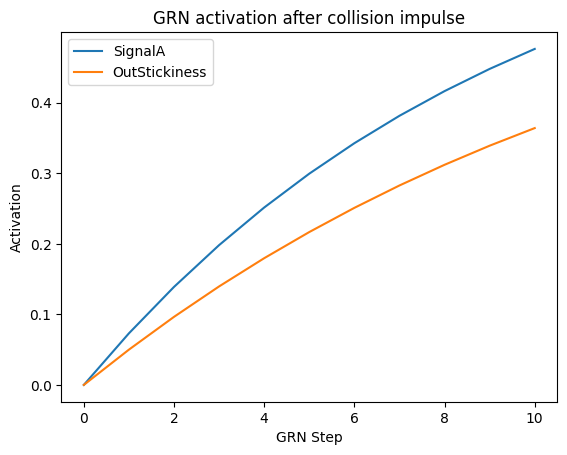

In [20]:
import matplotlib.pyplot as plt

signal_values = [state[1] for state in history]
stickiness_values = [state[2] for state in history]

plt.plot(signal_values, label="SignalA")
plt.plot(stickiness_values, label="OutStickiness")
plt.xlabel("GRN Step")
plt.ylabel("Activation")
plt.title("GRN activation after collision impulse")
plt.legend()
plt.show()

# GRN Smoke Test

This notebook validates the minimal GRN pipeline.

A collision impulse activates the input node **InCollisionImpulse**, which propagates through the network:

InCollisionImpulse → SignalA → OutStickiness

The plot shows that:

- SignalA activation increases over time
- OutStickiness increases more slowly due to downstream propagation

This confirms that the GRN signal propagation behaves as expected.